# Architecture Stage Inspection — HubertMultiTask
### End-to-end pipeline walkthrough · Publication-ready figures

Runs every stage of the pronunciation scoring model on a single audio file,  
printing tensor shapes and generating figures suitable for a paper or technical report.

**Pipeline:**
```
Raw audio  →  HuBERT (layer-weighted sum)  →  audio_proj  →  audio_transformer (pre-fusion)
           →  CrossAttentionFusion (Audio Q · Qwen3 text K/V)
           →  Transformer block (post-fusion)  →  mean pool
           →  MLPScoringHead × 5  +  prosody_feat_head × 5 (training aux)
```

| Figure | Stage | Content |
|--------|-------|---------|
| Fig 1 | Stage 1 | Waveform + log-power spectrogram |
| Fig 2 | Stage 2 | HuBERT layer-weight distribution |
| Fig 3 | Stage 2 | Mean frame norm vs learned weight (per layer) |
| Fig 4 | Stage 6 | Per-frame text modulation magnitude (cross-attention) |
| Fig 5 | Stage 7 | Frame L2-norm evolution across all pipeline stages |
| Fig 6 | Stage 9 | Score bar chart + radar |
| Fig 7 | Stage 11 | Pipeline tensor-shape summary table |

In [27]:
from pathlib import Path
import sys, json

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from models.hubert_multitask import HubertMultiTask
from models.asr_aligner      import ASRAligner, ASRConfig
from transformers             import AutoTokenizer
from utils.preprocessing      import preprocess_wav

# ── Publication-quality style ─────────────────────────────────────────────
mpl.rcParams.update({
    "font.family"        : "DejaVu Serif",
    "font.size"          : 11,
    "axes.titlesize"     : 12,
    "axes.labelsize"     : 11,
    "legend.fontsize"    : 10,
    "xtick.labelsize"    : 9,
    "ytick.labelsize"    : 9,
    "figure.dpi"         : 150,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "white",
    "axes.grid"          : True,
    "grid.alpha"         : 0.3,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "lines.linewidth"    : 1.5,
    "savefig.bbox"       : "tight",
    "savefig.dpi"        : 300,
})

# One colour per output dimension (total · accuracy · fluency · prosodic · completeness)
PALETTE = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"]

np.set_printoptions(precision=4, suppress=True)
torch.set_printoptions(precision=4, sci_mode=False)
print("Imports OK — repo root:", REPO_ROOT)

Imports OK — repo root: D:\pronunciation_scoring


In [ ]:
WAV_PATH  = "data/learner/01_learner.wav"   # ← change to your audio file
LANGUAGE  = "en"
DEVICE    = "cpu"
CKPT_PATH = "ckpt_hubert_multitask/best.pt"   # set None to use random weights

SAVE_FIGS = False          # True → save to FIG_DIR as PDF
FIG_DIR   = Path("docs/figures")

def savefig(name: str):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        path = FIG_DIR / name
        plt.savefig(path)
        print(f"  Saved → {path}")

# Model hyperparameters (must match checkpoint)
D_MODEL                      = 256
NUM_HEADS                    = 8
NUM_AUDIO_TRANSFORMER_LAYERS = 1
NUM_TRANSFORMER_LAYERS       = 2
MLP_HIDDEN_LAYERS            = 2
TEXT_MODEL                   = "Qwen/Qwen3-Embedding-0.6B"

model = HubertMultiTask(
    d_model                      = D_MODEL,
    num_heads                    = NUM_HEADS,
    num_audio_transformer_layers = NUM_AUDIO_TRANSFORMER_LAYERS,
    num_transformer_layers       = NUM_TRANSFORMER_LAYERS,
    mlp_hidden_layers            = MLP_HIDDEN_LAYERS,
    text_model_name              = TEXT_MODEL,
    num_unfreeze_hubert_layers   = 12,
).to(DEVICE).eval()

if CKPT_PATH:
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt)
    print(f"Checkpoint loaded: {CKPT_PATH}")
else:
    print("Random initialisation (no checkpoint).")

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParameters — total: {total_p:,}  |  trainable: {trainable_p:,}")
print(f"Config     — d_model={D_MODEL}, heads={NUM_HEADS}, "
      f"audio_layers={NUM_AUDIO_TRANSFORMER_LAYERS}, "
      f"post_layers={NUM_TRANSFORMER_LAYERS}, mlp_depth={MLP_HIDDEN_LAYERS}")

## Stage 1 · Raw Audio Preprocessing

`preprocess_wav()` → resample 16 kHz → peak-normalise → VAD-trim  
then zero-mean / unit-std normalisation per utterance (replacing `Wav2Vec2FeatureExtractor`):

```python
audio_norm = (audio - audio.mean()) / (audio.std() + 1e-7)
input_values = torch.tensor(audio_norm).unsqueeze(0)   # (1, T_samples)
```

**Fig 1** — Normalised waveform and log-power spectrogram.

Duration     : 5.76 s  |  samples: 92160  |  sr: 16000
input_values : (1, 92160)
Normalised   — mean: 0.000000  std: 0.999999


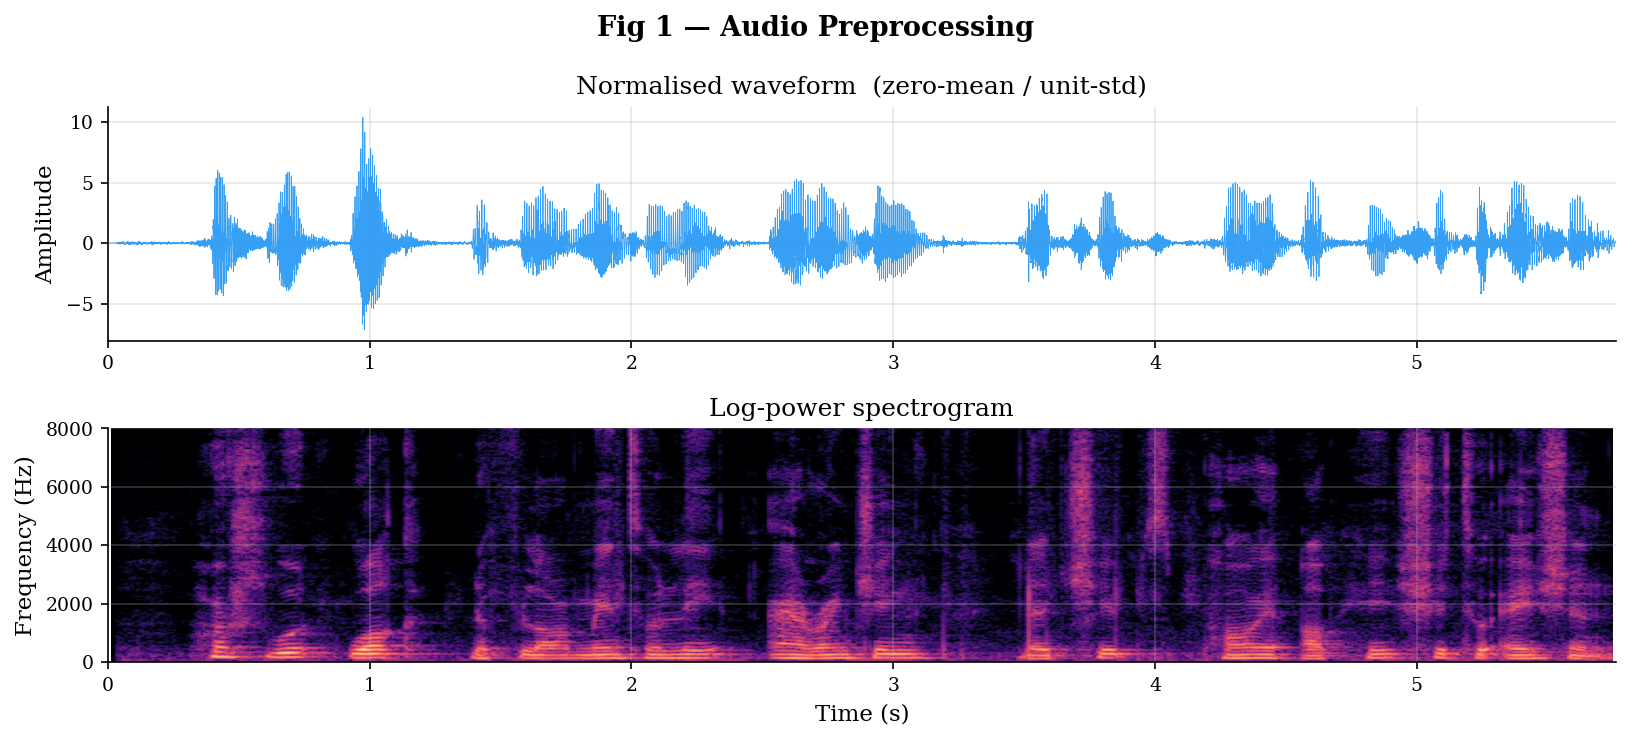

In [29]:
audio, sr = preprocess_wav(WAV_PATH, target_sr=16_000, use_vad=True)

def _normalize(arr: np.ndarray) -> np.ndarray:
    return (arr - arr.mean()) / (arr.std() + 1e-7)

audio_norm   = _normalize(audio)
input_values = torch.tensor(audio_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)
dur          = len(audio) / sr
t_audio      = np.linspace(0, dur, len(audio))

print(f"Duration     : {dur:.2f} s  |  samples: {len(audio)}  |  sr: {sr}")
print(f"input_values : {tuple(input_values.shape)}")
print(f"Normalised   — mean: {audio_norm.mean():.6f}  std: {audio_norm.std():.6f}")

# ── Fig 1: Waveform + spectrogram ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 5))
fig.suptitle("Fig 1 — Audio Preprocessing", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(t_audio, audio_norm, linewidth=0.4, color=PALETTE[0], alpha=0.9)
ax.set_ylabel("Amplitude")
ax.set_xlim(0, dur)
ax.set_title("Normalised waveform  (zero-mean / unit-std)")

ax = axes[1]
ax.specgram(audio_norm, Fs=sr, NFFT=512, noverlap=384, cmap="magma", vmin=-80, vmax=0)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Log-power spectrogram")
ax.set_ylim(0, 8000)
ax.set_xlim(0, dur)

plt.tight_layout()
savefig("fig1_preprocessing.pdf")
plt.show()

## Stage 2 · HuBERT Layer-Weighted Encoding

HuBERT produces **13 hidden states** (1 CNN embedding layer + 12 Transformer layers).  
A learnable `layer_weights` vector (softmaxed at runtime) weights each layer's contribution:

```
hidden_states : 13 × (B, T, 768)
layer_weights :     (13,)   softmax  →  Σ  →  (B, T, 768)
```

**Fig 2** — Softmax weight per layer (reveals learned layer importance).  
**Fig 3** — Mean per-frame L2 norm vs learned weight (scatter plot per layer).

HuBERT output — T_frames=287, frame_hz=49.8 Hz, H=768
  num hidden states: 13

Layer weights — entropy: 2.565  (max=2.565 = uniform)
  Top layer: 0  (weight=0.0769)


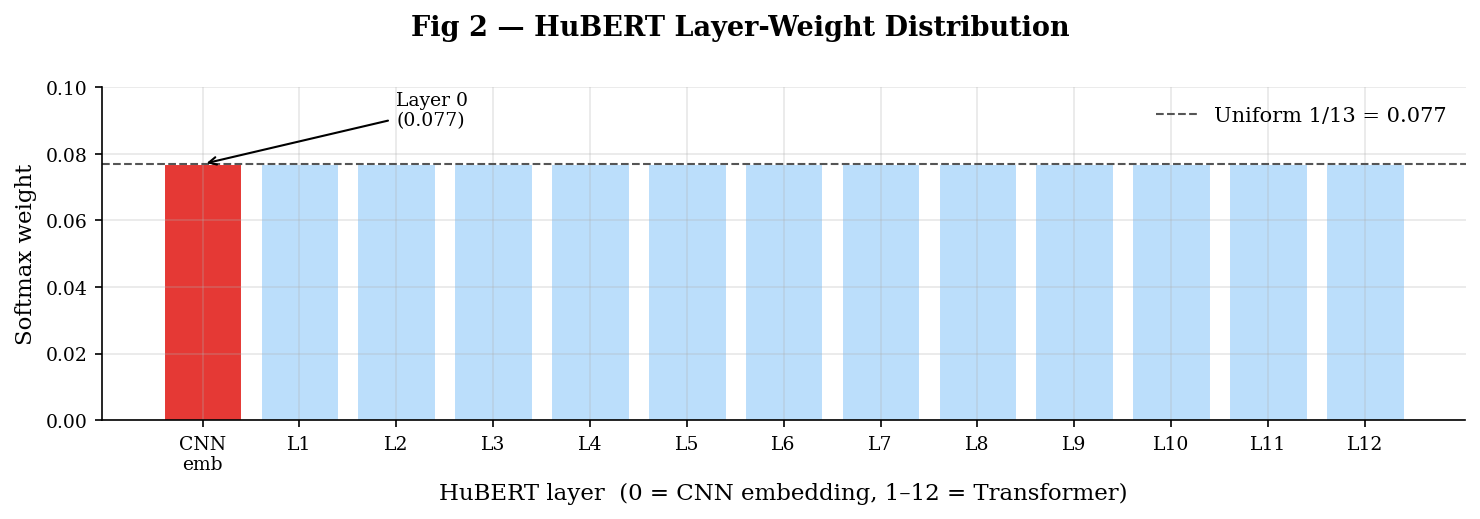

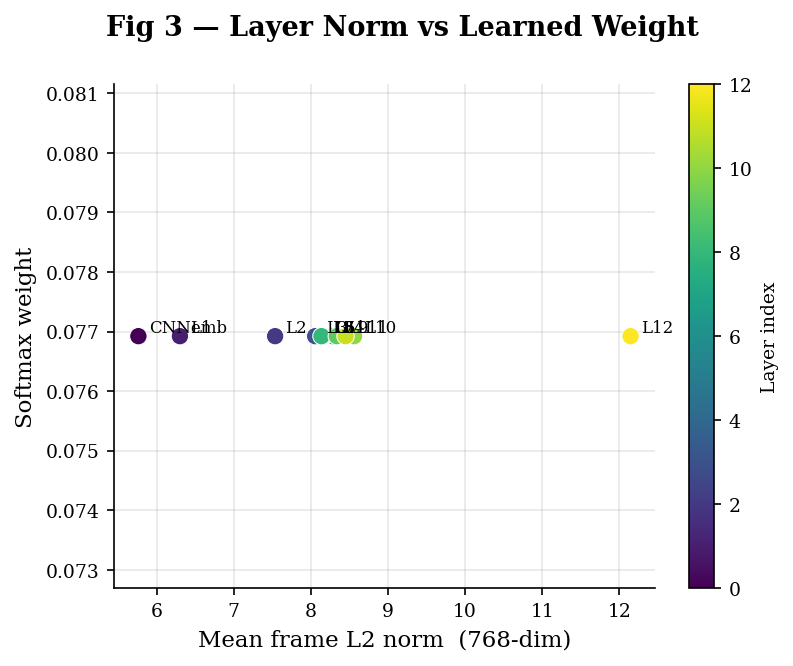


_layer_weighted_encode output shape : (1, 287, 768)
  frame norm  min/mean/max : 4.923 / 6.363 / 7.092


In [30]:
with torch.no_grad():
    hubert_out = model.hubert(input_values=input_values, output_hidden_states=True)

hidden_states = hubert_out.hidden_states        # tuple of 13: each (1, T, 768)
T_frames      = hidden_states[0].shape[1]
frame_hz      = T_frames / dur
t_frames      = np.arange(T_frames) / frame_hz  # frame time axis (seconds)

print(f"HuBERT output — T_frames={T_frames}, frame_hz={frame_hz:.1f} Hz, H=768")
print(f"  num hidden states: {len(hidden_states)}")

# Learned layer weights and per-layer mean frame norm
weights_np  = torch.softmax(model.layer_weights.detach().cpu(), dim=0).numpy()
layer_norms = np.array([hs[0].norm(dim=-1).mean().item() for hs in hidden_states])
layer_labels = ["CNN\nemb"] + [f"L{i}" for i in range(1, 13)]

top_layer = int(weights_np.argmax())
entropy   = float(-(weights_np * np.log(weights_np + 1e-12)).sum())
print(f"\nLayer weights — entropy: {entropy:.3f}  (max={np.log(13):.3f} = uniform)")
print(f"  Top layer: {top_layer}  (weight={weights_np[top_layer]:.4f})")

# ── Fig 2: Layer weight distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
fig.suptitle("Fig 2 — HuBERT Layer-Weight Distribution", fontsize=13, fontweight="bold")

bar_colors = ["#BBDEFB"] * 13
bar_colors[0]         = "#90CAF9"   # CNN embedding
bar_colors[top_layer] = "#E53935"   # highest-weight layer

bars = ax.bar(layer_labels, weights_np, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axhline(1 / 13, color="#555555", linestyle="--", linewidth=1,
           label=f"Uniform 1/13 = {1/13:.3f}")
ax.set_xlabel("HuBERT layer  (0 = CNN embedding, 1–12 = Transformer)")
ax.set_ylabel("Softmax weight")
ax.set_ylim(0, weights_np.max() * 1.3)
ax.legend(frameon=False)
ax.annotate(
    f"Layer {top_layer}\n({weights_np[top_layer]:.3f})",
    xy=(top_layer, weights_np[top_layer]),
    xytext=(min(top_layer + 2, 11), weights_np[top_layer] * 1.15),
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
    fontsize=9,
)
plt.tight_layout()
savefig("fig2_layer_weights.pdf")
plt.show()

# ── Fig 3: Per-layer norm vs weight scatter ────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))
fig.suptitle("Fig 3 — Layer Norm vs Learned Weight", fontsize=13, fontweight="bold")

sc = ax.scatter(layer_norms, weights_np, c=range(13), cmap="viridis",
                s=70, zorder=3, edgecolors="white", linewidths=0.5)
for i, (x, y) in enumerate(zip(layer_norms, weights_np)):
    ax.annotate(layer_labels[i].replace("\n", ""),
                (x, y), textcoords="offset points", xytext=(5, 2), fontsize=8)
ax.set_xlabel("Mean frame L2 norm  (768-dim)")
ax.set_ylabel("Softmax weight")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Layer index", fontsize=9)
plt.tight_layout()
savefig("fig3_norm_vs_weight.pdf")
plt.show()

# Compute layer-weighted sum
with torch.no_grad():
    lw_out = model._layer_weighted_encode(input_values)   # (1, T, 768)

norms_lw = lw_out[0].norm(dim=-1).cpu().numpy()   # (T,)  — track for Fig 5
print(f"\n_layer_weighted_encode output shape : {tuple(lw_out.shape)}")
print(f"  frame norm  min/mean/max : {norms_lw.min():.3f} / {norms_lw.mean():.3f} / {norms_lw.max():.3f}")

## Stage 3 · Audio Linear Projection

`audio_proj` maps each HuBERT frame embedding from the backbone hidden size (768) to the shared model dimension (256):

```
(B, T, 768)  →  Linear(768, 256)  →  (B, T, 256)
```

In [31]:
with torch.no_grad():
    audio_proj_out = model.audio_proj(lw_out)   # (1, T, 256)

norms_proj = audio_proj_out[0].norm(dim=-1).cpu().numpy()   # (T,) — for Fig 5
print(f"audio_proj output shape : {tuple(audio_proj_out.shape)}")
print(f"  frame norm  min/mean/max : {norms_proj.min():.4f} / {norms_proj.mean():.4f} / {norms_proj.max():.4f}")
print(f"  first frame (dims 0–7)  : {audio_proj_out[0, 0, :8]}")

audio_proj output shape : (1, 287, 256)
  frame norm  min/mean/max : 1.6326 / 2.1559 / 2.5427
  first frame (dims 0–7)  : tensor([-0.0464, -0.1656, -0.1342, -0.1304,  0.0756,  0.2214, -0.1153, -0.0053])


## Stage 4 · Pre-fusion Audio Self-Attention

A shallow Transformer encoder (Pre-LN, `norm_first=True`) contextualises audio frames **within the utterance** before cross-modal fusion:

```
(B, T, 256)  →  TransformerEncoder(d_model=256, nhead=8, norm_first=True, layers=1)
             →  (B, T, 256)
```

Set `num_audio_transformer_layers=0` to disable (identity pass-through).

In [32]:
if model.audio_transformer is not None:
    with torch.no_grad():
        audio_transformer_out = model.audio_transformer(audio_proj_out)   # (1, T, 256)
    delta_mean = (audio_transformer_out - audio_proj_out).abs().mean().item()
    print(f"audio_transformer output shape  : {tuple(audio_transformer_out.shape)}")
    print(f"  mean |delta| from audio_proj  : {delta_mean:.6f}  (0 ≡ identity)")
else:
    audio_transformer_out = audio_proj_out
    print("audio_transformer disabled — identity pass-through.")

norms_atrans = audio_transformer_out[0].norm(dim=-1).cpu().numpy()   # (T,) — for Fig 5
print(f"  frame norm  min/mean/max : {norms_atrans.min():.4f} / {norms_atrans.mean():.4f} / {norms_atrans.max():.4f}")

audio_transformer output shape  : (1, 287, 256)
  mean |delta| from audio_proj  : 0.209483  (0 ≡ identity)
  frame norm  min/mean/max : 4.2646 / 4.7708 / 5.2033


## Stage 5 · Text Encoding (Qwen3-Embedding-0.6B)

The ASR transcript is tokenised and passed through the frozen Qwen3 decoder model.  
**Mask-aware mean pooling** is used (not CLS — Qwen3 is a decoder-style model):

```
tokens (B, L)  →  Qwen3  →  last_hidden_state (B, L, 1024)
               →  Σ masked tokens / count          →  (B, 1024)
               →  Linear(1024, 256) + LayerNorm    →  (B, 1, 256)   [K/V in cross-attn]
```

In [33]:
# ASR transcript
print("Running ASR…")
aligner    = ASRAligner(ASRConfig(model_size="small", device=DEVICE, compute_type="int8"))
asr        = aligner.transcribe_with_timestamps(audio, sr=sr, language=LANGUAGE)
transcript = asr["text"].strip()
words      = asr.get("words", [])

print(f"Transcript : {transcript!r}")
print(f"Words      : {len(words)}  |  Duration: {asr.get('duration', dur):.2f} s")

# Word timestamps (used later for frame-aligned overlays)
word_starts = [w["start"] for w in words if "start" in w]
word_ends   = [w["end"]   for w in words if "end"   in w]
word_labels = [w["word"]  for w in words if "word"  in w]

# Tokenise for Qwen3
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL)
enc = text_tokenizer(
    transcript,
    return_tensors = "pt",
    padding        = True,
    truncation     = True,
    max_length     = 512,
)
text_input_ids      = enc["input_ids"].to(DEVICE)
text_attention_mask = enc["attention_mask"].to(DEVICE)
n_tokens            = int(text_attention_mask.sum())

print(f"\nTokenised — shape: {tuple(text_input_ids.shape)}  |  non-pad tokens: {n_tokens}")

# Encode text
with torch.no_grad():
    raw_text_emb = model._encode_text(text_input_ids, text_attention_mask)   # (1, 1024)
    text_emb_kv  = model.text_proj(raw_text_emb).unsqueeze(1)               # (1, 1, 256)

print(f"_encode_text shape  : {tuple(raw_text_emb.shape)}")
print(f"text_emb_kv shape   : {tuple(text_emb_kv.shape)}  (K/V for cross-attention)")

Running ASR…
Transcript : "Hertz would walk the floor mentally arranging the chip's point of his situation."
Words      : 13  |  Duration: 5.76 s

Tokenised — shape: (1, 17)  |  non-pad tokens: 17
_encode_text shape  : (1, 1024)
text_emb_kv shape   : (1, 1, 256)  (K/V for cross-attention)


## Stage 6 · Cross-Attention Fusion

Audio frames are **queries**; the projected text sentence embedding is **keys and values**:

```
Audio Q : (B, T, 256)   ←  audio_transformer output
Text K/V: (B, 1, 256)   ←  text_proj output  (single sentence vector)

MultiheadAttention(audio_Q, text_K, text_V)  →  (B, T, 256)
LayerNorm( audio_Q + dropout(attn_out) )      →  (B, T, 256)
```

Since K/V has length 1, attention weights are trivially uniform across frames.  
The meaningful signal is the **per-frame modulation magnitude** `‖fused − pre-fusion‖₂`,  
which shows which audio frames were most influenced by the cross-modal text signal.

**Fig 4** — Per-frame text modulation, overlaid with ASR word boundaries.

CrossAttentionFusion output shape : (1, 287, 256)
  mean text modulation ‖Δ‖₂      : 13.5052
  frame norm  min/mean/max        : 15.9996 / 15.9997 / 15.9997


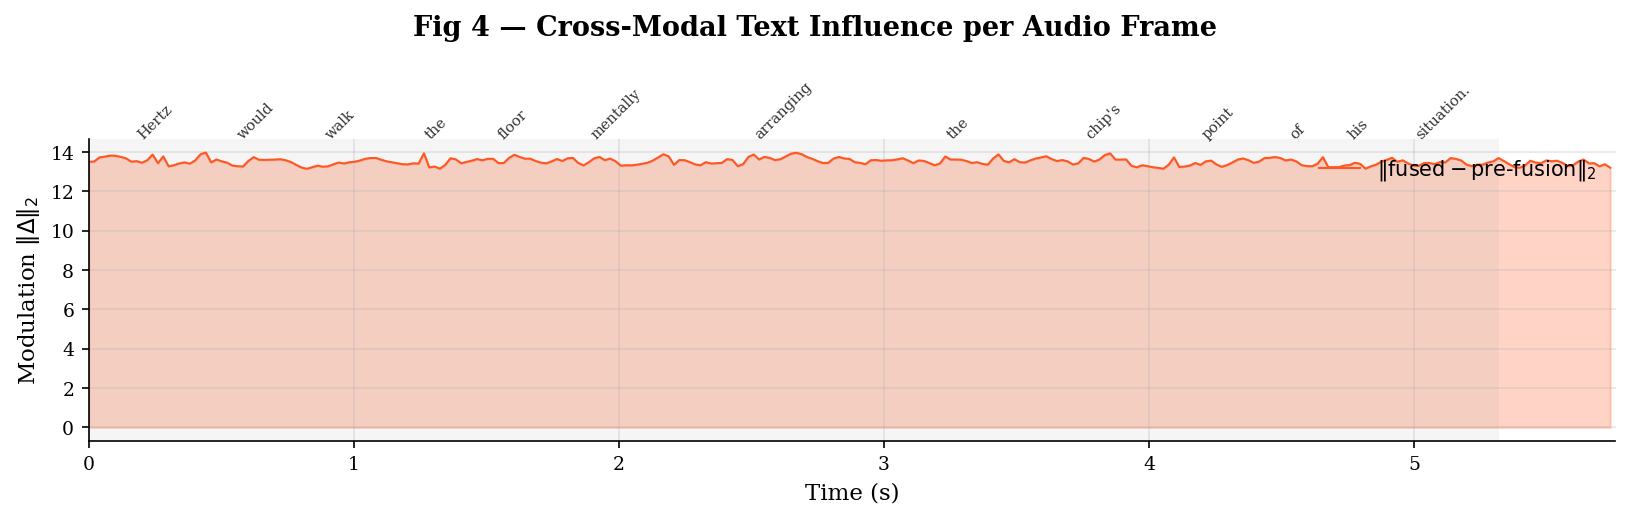

In [34]:
with torch.no_grad():
    fused = model.cross_attn_fusion(audio_transformer_out, text_emb_kv)   # (1, T, 256)

norms_fused      = fused[0].norm(dim=-1).cpu().numpy()                              # (T,) — for Fig 5
delta_per_frame  = (fused - audio_transformer_out)[0].norm(dim=-1).cpu().numpy()    # (T,) text influence

print(f"CrossAttentionFusion output shape : {tuple(fused.shape)}")
print(f"  mean text modulation ‖Δ‖₂      : {delta_per_frame.mean():.4f}")
print(f"  frame norm  min/mean/max        : {norms_fused.min():.4f} / {norms_fused.mean():.4f} / {norms_fused.max():.4f}")

# ── Fig 4: Per-frame text modulation + word boundaries ────────────────────
fig, ax = plt.subplots(figsize=(11, 3.5))
fig.suptitle("Fig 4 — Cross-Modal Text Influence per Audio Frame", fontsize=13, fontweight="bold")

ax.fill_between(t_frames, delta_per_frame, alpha=0.25, color=PALETTE[1])
ax.plot(t_frames, delta_per_frame, linewidth=1.0, color=PALETTE[1],
        label=r"$\|\mathrm{fused} - \mathrm{pre\text{-}fusion}\|_2$")

# Word boundary shading + labels
for s, e, w in zip(word_starts, word_ends, word_labels):
    ax.axvspan(s, e, alpha=0.08, color="#888888", linewidth=0)
    mid = (s + e) / 2
    ax.text(mid, delta_per_frame.max() * 1.04, w.strip(),
            ha="center", va="bottom", fontsize=7, rotation=45, color="#333333")

ax.set_xlabel("Time (s)")
ax.set_ylabel(r"Modulation $\|\Delta\|_2$")
ax.set_xlim(0, dur)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
savefig("fig4_text_modulation.pdf")
plt.show()

## Stage 7 · Post-fusion Transformer Block

A deeper Transformer encoder (Pre-LN, 2 layers) contextualises the fused sequence:

```
(B, T, 256)  →  TransformerEncoder(d_model=256, nhead=8, norm_first=True, layers=2)
             →  (B, T, 256)
```

**Fig 5** — Per-frame L2 norm at every pipeline stage in ℝ²⁵⁶  
(HuBERT norms are in ℝ⁷⁶⁸ and shown on a separate subplot for reference).

Post-fusion transformer output shape : (1, 287, 256)
  frame norm  min/mean/max : 19.9726 / 20.8896 / 21.8053


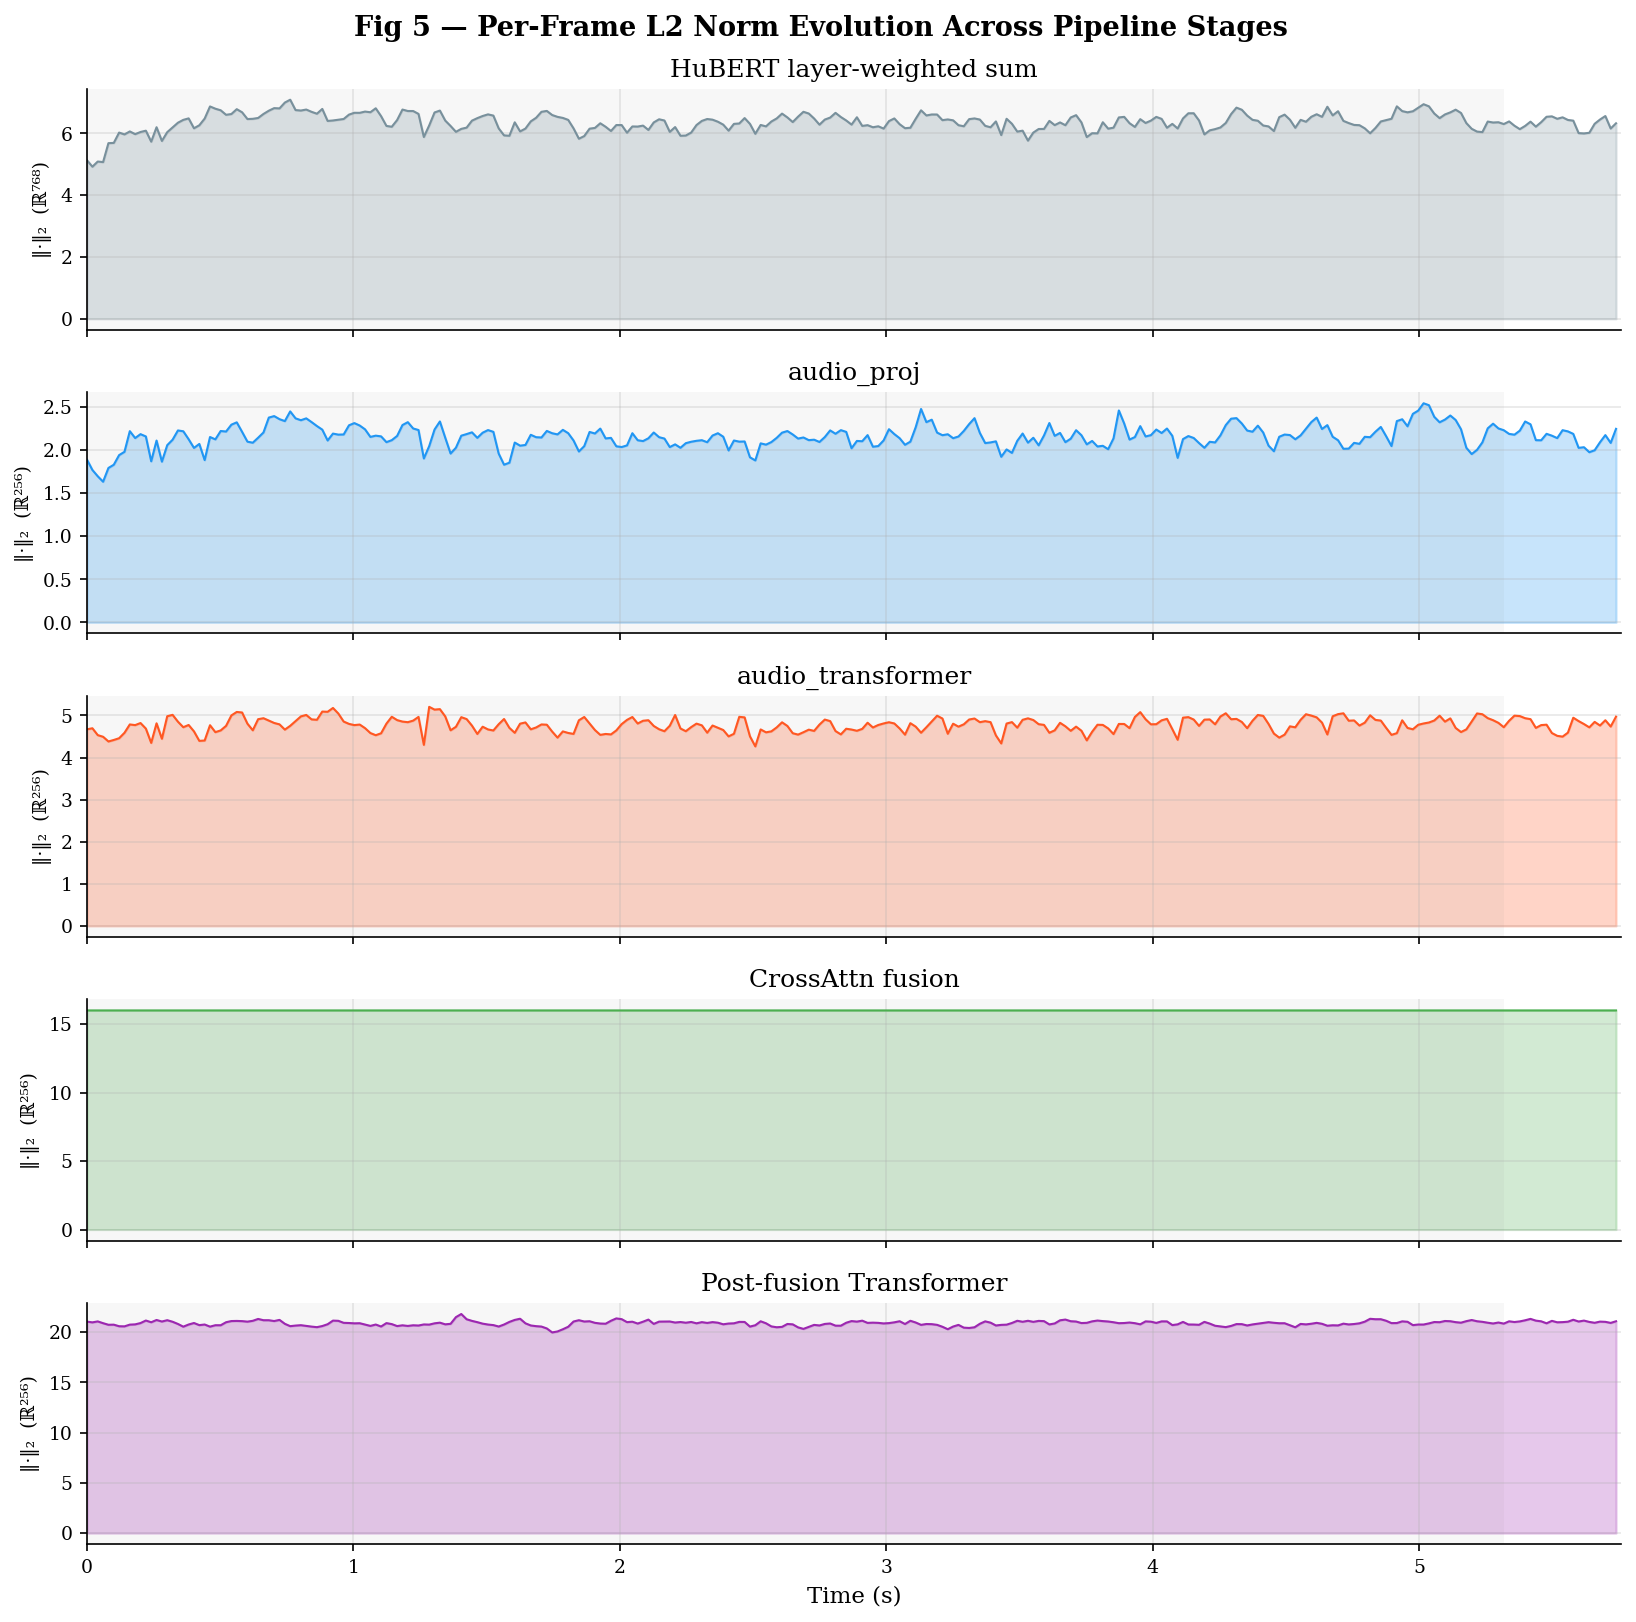


Stage                             dim      min     mean      max
------------------------------------------------------------
HuBERT lw-sum (ℝ⁷⁶⁸)              768   4.9234   6.3629   7.0920
audio_proj                        256   1.6326   2.1559   2.5427
audio_transformer                 256   4.2646   4.7708   5.2033
CrossAttn fusion                  256  15.9996  15.9997  15.9997
Post-fusion Transformer           256  19.9726  20.8896  21.8053


In [35]:
with torch.no_grad():
    refined = model.transformer(fused)   # (1, T, 256)

norms_refined = refined[0].norm(dim=-1).cpu().numpy()   # (T,)
print(f"Post-fusion transformer output shape : {tuple(refined.shape)}")
print(f"  frame norm  min/mean/max : {norms_refined.min():.4f} / {norms_refined.mean():.4f} / {norms_refined.max():.4f}")

# ── Fig 5: Frame L2-norm evolution across pipeline stages ─────────────────
# Two groups: HuBERT (768-dim) on its own subplot; d_model stages (256-dim) together.
d_model_stages = {
    "audio_proj"             : norms_proj,
    "audio_transformer"      : norms_atrans,
    "CrossAttn fusion"       : norms_fused,
    "Post-fusion Transformer": norms_refined,
}

fig, axes = plt.subplots(5, 1, figsize=(11, 11), sharex=True)
fig.suptitle("Fig 5 — Per-Frame L2 Norm Evolution Across Pipeline Stages",
             fontsize=13, fontweight="bold")

# Top subplot: HuBERT layer-weighted (ℝ⁷⁶⁸)
ax = axes[0]
ax.fill_between(t_frames, norms_lw, alpha=0.25, color="#78909C")
ax.plot(t_frames, norms_lw, linewidth=1.0, color="#78909C")
ax.set_ylabel("‖·‖₂  (ℝ⁷⁶⁸)", fontsize=9)
ax.set_title("HuBERT layer-weighted sum")
for s, e in zip(word_starts, word_ends):
    ax.axvspan(s, e, alpha=0.06, color="gray", linewidth=0)

# Four subplots for ℝ²⁵⁶ stages
for ax, (name, norms), color in zip(axes[1:], d_model_stages.items(), PALETTE):
    ax.fill_between(t_frames, norms, alpha=0.25, color=color)
    ax.plot(t_frames, norms, linewidth=1.0, color=color)
    ax.set_ylabel("‖·‖₂  (ℝ²⁵⁶)", fontsize=9)
    ax.set_title(name)
    for s, e in zip(word_starts, word_ends):
        ax.axvspan(s, e, alpha=0.06, color="gray", linewidth=0)

axes[-1].set_xlabel("Time (s)")
for ax in axes:
    ax.set_xlim(0, dur)

plt.tight_layout()
savefig("fig5_norm_evolution.pdf")
plt.show()

# Summary table
print(f"\n{'Stage':<30}  {'dim':>5}  {'min':>7}  {'mean':>7}  {'max':>7}")
print("-" * 60)
all_stages = {"HuBERT lw-sum (ℝ⁷⁶⁸)": (norms_lw, 768), **{k: (v, 256) for k, v in d_model_stages.items()}}
for name, (norms, dim) in all_stages.items():
    print(f"{name:<30}  {dim:>5}  {norms.min():7.4f}  {norms.mean():7.4f}  {norms.max():7.4f}")

## Stage 8 · Utterance-Level Mean Pooling

Mean pool over the time dimension collapses the sequence to a single utterance embedding:

```
(B, T, 256)  →  .mean(dim=1)  →  (B, 256)
```

utt_emb shape : (1, 256)  |  L2 norm: 19.8711
  value range : [-4.0202, 3.4731]  |  std: 1.2419


C:\Users\nhl08\AppData\Local\Temp\ipykernel_12460\374175799.py:27: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
d:\pronunciation_scoring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


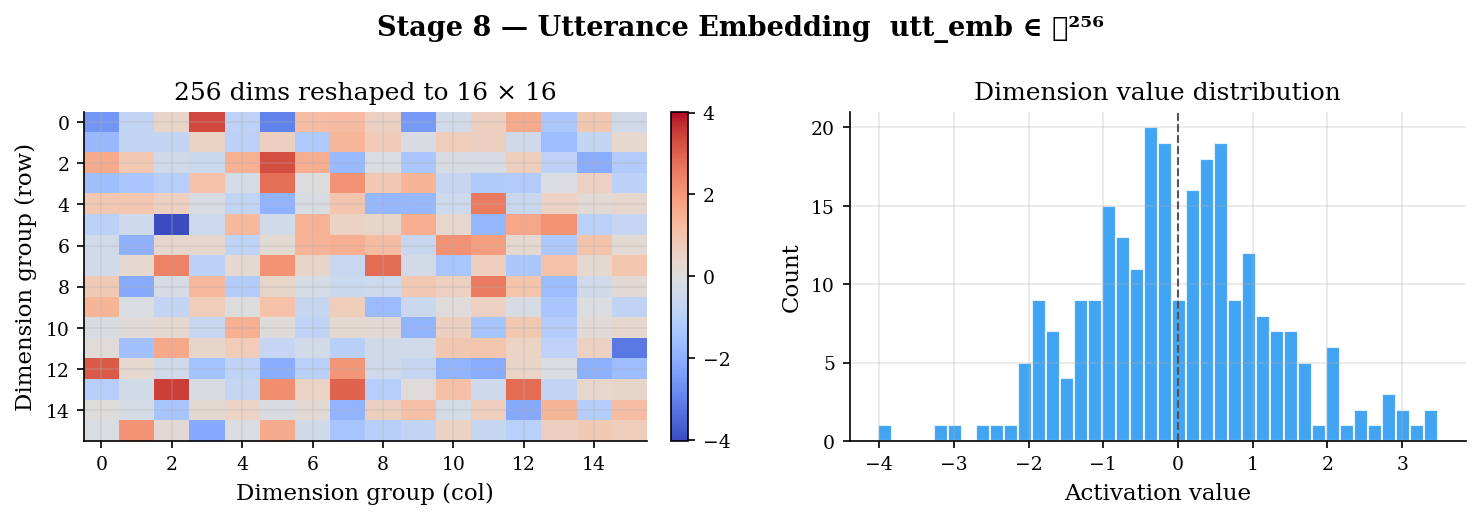

In [36]:
with torch.no_grad():
    utt_emb = refined.mean(dim=1)   # (1, 256)

emb_np = utt_emb[0].cpu().numpy()   # (256,)
print(f"utt_emb shape : {tuple(utt_emb.shape)}  |  L2 norm: {utt_emb.norm().item():.4f}")
print(f"  value range : [{emb_np.min():.4f}, {emb_np.max():.4f}]  |  std: {emb_np.std():.4f}")

# Visualise as 16×16 heatmap + value histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle("Stage 8 — Utterance Embedding  utt_emb ∈ ℝ²⁵⁶", fontsize=13, fontweight="bold")

ax = axes[0]
im = ax.imshow(emb_np.reshape(16, 16), cmap="coolwarm", aspect="auto",
               vmin=-np.abs(emb_np).max(), vmax=np.abs(emb_np).max())
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("256 dims reshaped to 16 × 16")
ax.set_xlabel("Dimension group (col)")
ax.set_ylabel("Dimension group (row)")

ax = axes[1]
ax.hist(emb_np, bins=40, color=PALETTE[0], alpha=0.85, edgecolor="white")
ax.axvline(0, color="#555555", linestyle="--", linewidth=1)
ax.set_xlabel("Activation value")
ax.set_ylabel("Count")
ax.set_title("Dimension value distribution")

plt.tight_layout()
plt.show()

## Stage 9 · MLP Scoring Head

`MLPScoringHead` maps `utt_emb` to **5 pronunciation scores** ∈ [0, 1]:

```
(B, 256)
  →  [ Linear(256, 256) → ReLU → Dropout ] × mlp_hidden_layers
  →  Linear(256, 5)  →  Sigmoid  →  (B, 5)
```

Multiply by 10 to recover SpeechOcean-style [0, 10] scores at inference time.  
Output dimensions: **total · accuracy · fluency · prosodic · completeness**

**Fig 6** — Score bar chart and radar plot.

MLPScoringHead output shape : (1, 5)

Dimension         [0,1]   [0,10]
---------------------------------
total            0.5111     5.11
accuracy         0.5047     5.05
fluency          0.4831     4.83
prosodic         0.5382     5.38
completeness     0.5279     5.28


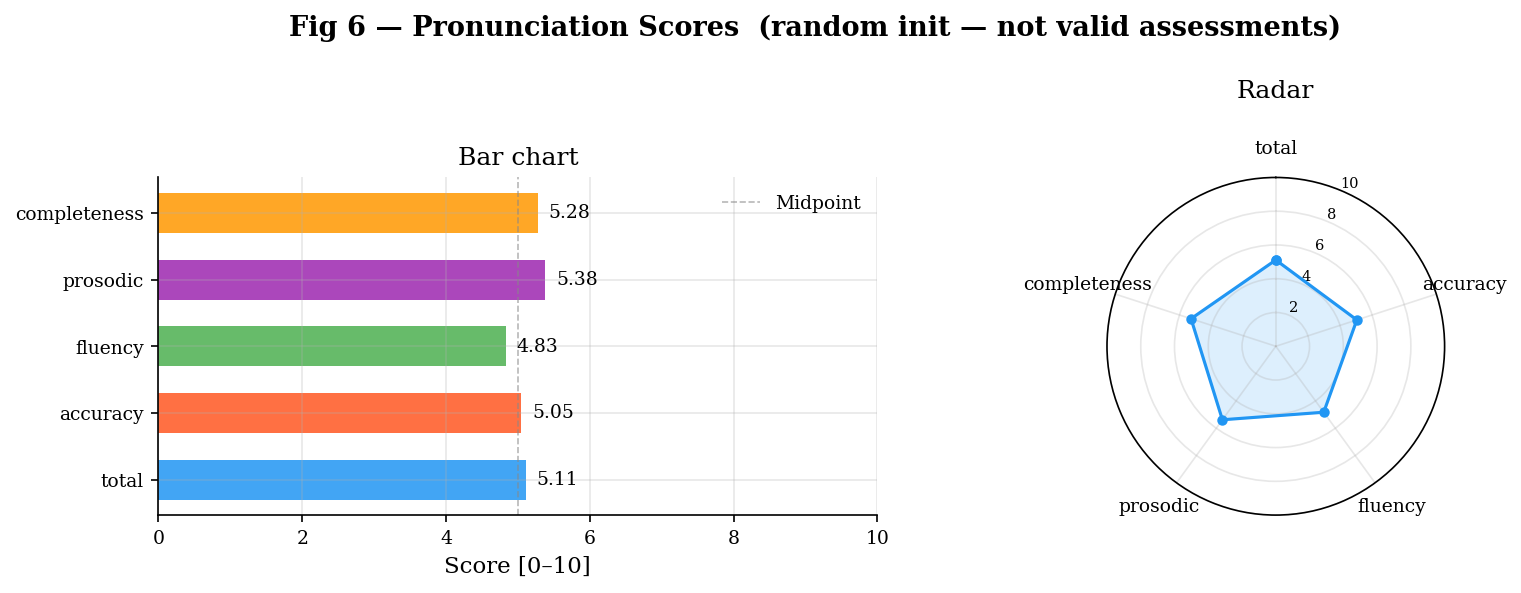

In [37]:
SENT_DIMS = ["total", "accuracy", "fluency", "prosodic", "completeness"]

with torch.no_grad():
    sent_pred = model.scorer(utt_emb)   # (1, 5)

pred_np = sent_pred.cpu().numpy()[0]   # [0, 1]
scaled  = pred_np * 10                 # [0, 10]

print(f"MLPScoringHead output shape : {tuple(sent_pred.shape)}")
print(f"\n{'Dimension':<15}  {'[0,1]':>6}  {'[0,10]':>7}")
print("-" * 33)
for dim, v, s in zip(SENT_DIMS, pred_np, scaled):
    print(f"{dim:<15}  {v:6.4f}  {s:7.2f}")

# ── Fig 6: Bar chart + radar ───────────────────────────────────────────────
fig = plt.figure(figsize=(11, 4))
fig.suptitle("Fig 6 — Pronunciation Scores  (random init — not valid assessments)",
             fontsize=13, fontweight="bold")
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.1, 1])

# Horizontal bar chart
ax1 = fig.add_subplot(gs[0])
y    = np.arange(len(SENT_DIMS))
bars = ax1.barh(y, scaled, color=PALETTE, alpha=0.85, height=0.6)
ax1.set_yticks(y)
ax1.set_yticklabels(SENT_DIMS)
ax1.set_xlabel("Score [0–10]")
ax1.set_xlim(0, 10)
ax1.axvline(5, color="#888888", linestyle="--", linewidth=0.8, alpha=0.6, label="Midpoint")
for bar, v in zip(bars, scaled):
    ax1.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
             f"{v:.2f}", va="center", fontsize=9)
ax1.set_title("Bar chart")
ax1.legend(frameon=False, fontsize=9)

# Radar chart
ax2    = fig.add_subplot(gs[1], polar=True)
N      = len(SENT_DIMS)
angs   = np.linspace(0, 2 * np.pi, N, endpoint=False)
vals_c = scaled.tolist() + [scaled[0]]
angs_c = np.append(angs, angs[0])

ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_ylim(0, 10)
ax2.set_yticks([2, 4, 6, 8, 10])
ax2.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7)
ax2.plot(angs_c, vals_c, "o-", linewidth=1.5, color=PALETTE[0], markersize=4)
ax2.fill(angs_c, vals_c, alpha=0.15, color=PALETTE[0])
ax2.set_xticks(angs)
ax2.set_xticklabels(SENT_DIMS, fontsize=9)
ax2.set_title("Radar", pad=20)

plt.tight_layout()
savefig("fig6_scores.pdf")
plt.show()

## Stage 10 · Auxiliary Prosody Feature Head

During training only — predicts normalised prosody features from `utt_emb`:

```
(B, 256)  →  Linear(256, 256) → ReLU → Dropout → Linear(256, 5)  →  (B, 5)  [unbounded]
```

Targets: `rms · zcr · peak_rate · f0_mean · f0_std`  (audio-computed, normalised per batch).  
This head is **discarded at inference**; it acts as a regulariser that steers `utt_emb` towards prosody-aware representations.

In [38]:
PROSODY_DIMS = ["rms", "zcr", "peak_rate", "f0_mean", "f0_std"]

with torch.no_grad():
    prosody_pred = model.prosody_feat_head(utt_emb)   # (1, 5)

pr_np = prosody_pred.cpu().numpy()[0]
print(f"prosody_feat_head output shape : {tuple(prosody_pred.shape)}")
print(f"\n{'Dimension':<12}  {'Raw Pred':>10}  {'Note'}")
print("-" * 46)
for dim, v in zip(PROSODY_DIMS, pr_np):
    note = "(Hz, normalised)" if "f0" in dim else "(normalised)"
    print(f"{dim:<12}  {v:10.4f}  {note}")

prosody_feat_head output shape : (1, 5)

Dimension       Raw Pred  Note
----------------------------------------------
rms              -0.2088  (normalised)
zcr              -0.5173  (normalised)
peak_rate         0.1226  (normalised)
f0_mean           0.3216  (Hz, normalised)
f0_std            0.2859  (Hz, normalised)


## Stage 11 · Loss Computation, Gradient Check & Pipeline Summary

`compute_loss()` combines two MSE terms:

| Term | Default weight | Supervises |
|------|---------------|------------|
| `w_sent`  | 1.0 | Sentence scores (5-dim, target ÷ 10) |
| `w_pfeat` | 0.2 | Prosody features (5-dim, normalised audio stats) |

The backward pass verifies that **all trainable parameters receive gradients**.

**Fig 7** — Pipeline tensor-shape summary table (paper-ready).

Loss components:
  loss_total        : 0.274938
  loss_sent         : 0.196283
  loss_prosody      : 0.393276

Trainable params with gradient    : 222
Trainable params WITHOUT gradient : 48
  ⚠  Missing (first 10):
     hubert.encoder.layers.1.attention.k_proj.weight
     hubert.encoder.layers.1.attention.k_proj.bias
     hubert.encoder.layers.1.attention.v_proj.weight
     hubert.encoder.layers.1.attention.v_proj.bias
     hubert.encoder.layers.1.attention.q_proj.weight
     hubert.encoder.layers.1.attention.q_proj.bias
     hubert.encoder.layers.1.attention.out_proj.weight
     hubert.encoder.layers.1.attention.out_proj.bias
     hubert.encoder.layers.1.layer_norm.weight
     hubert.encoder.layers.1.layer_norm.bias


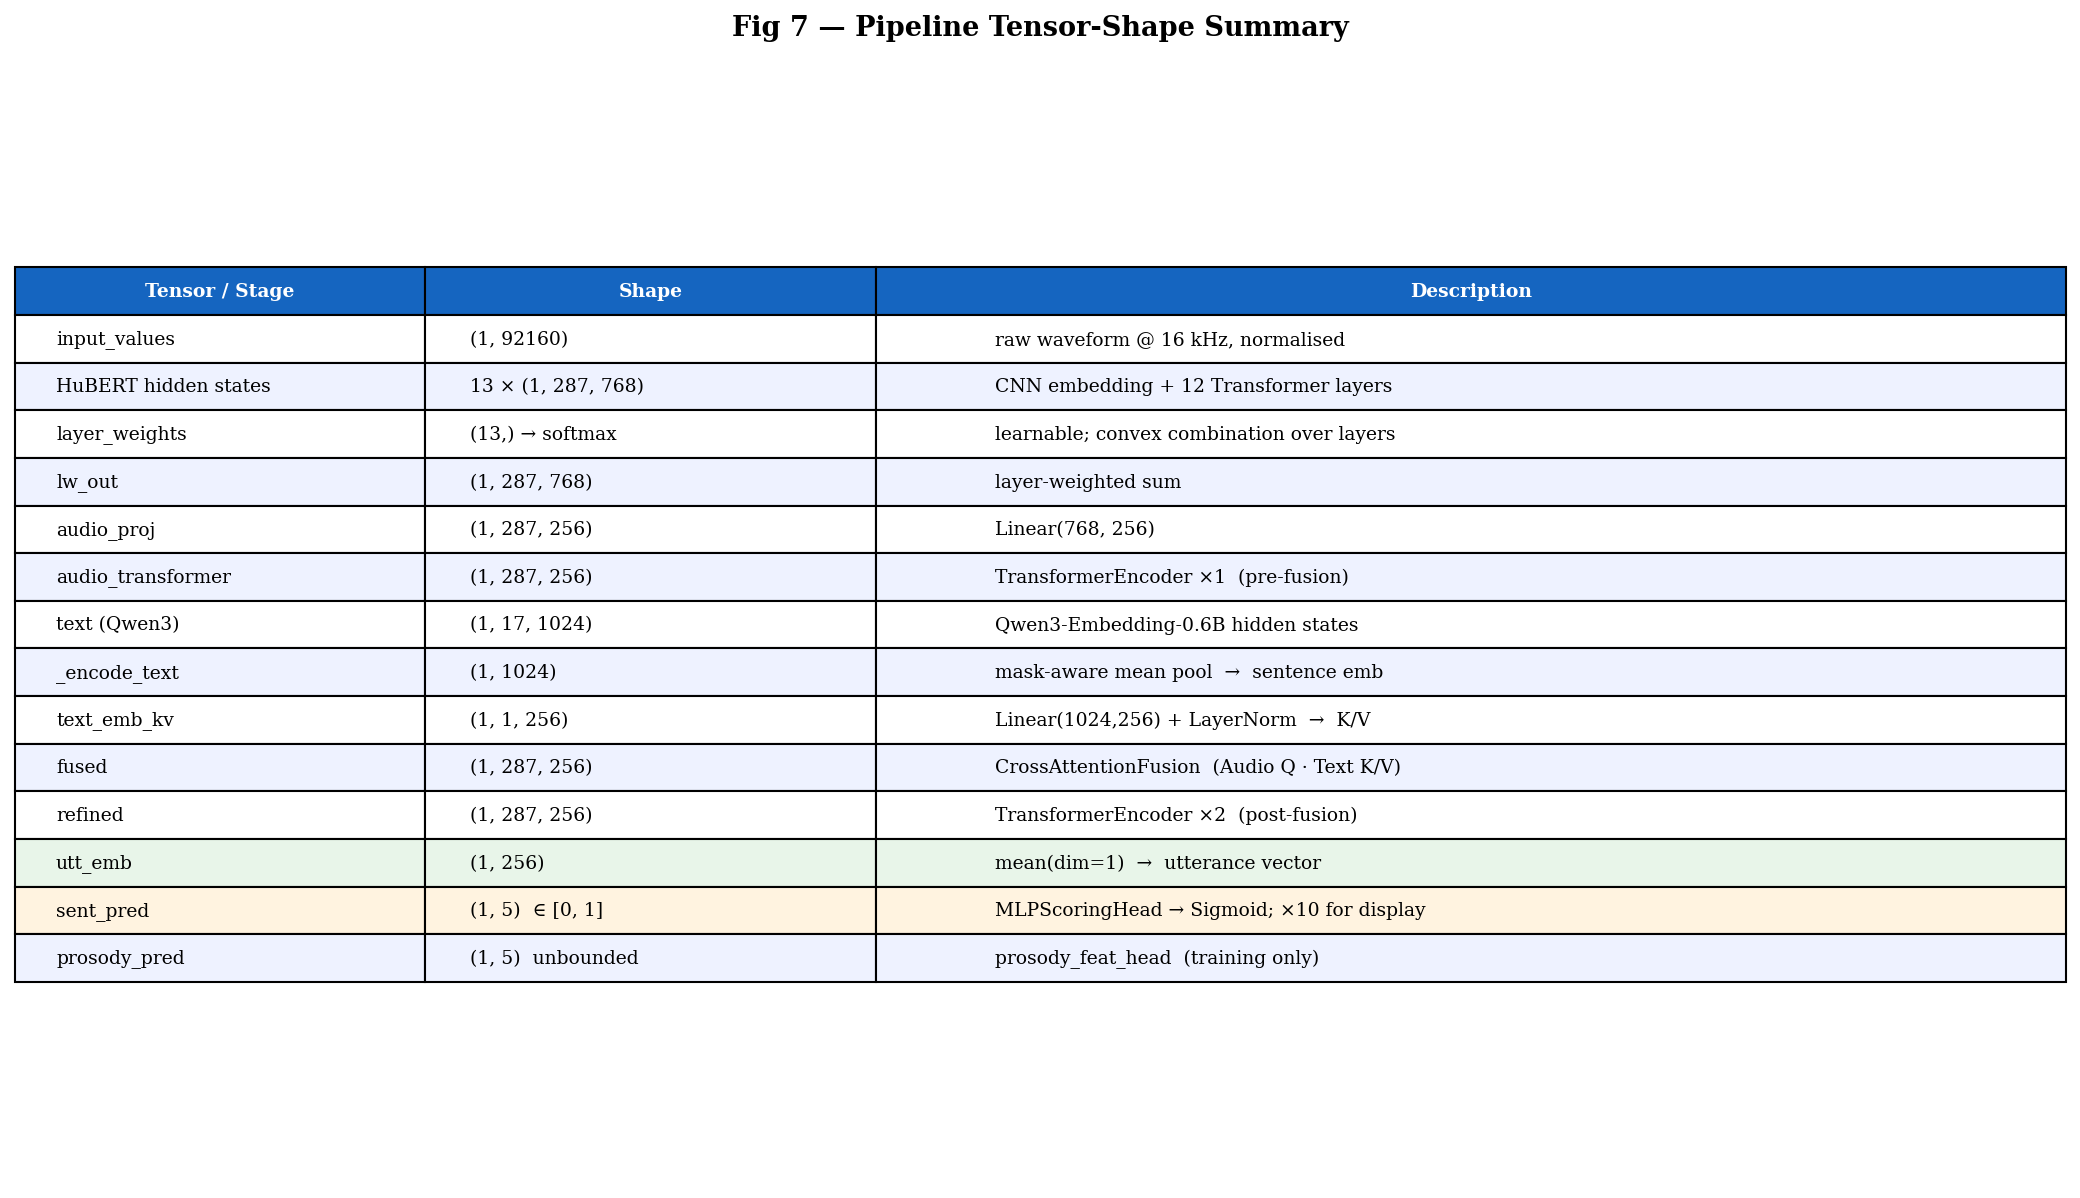

In [39]:
from models.train import compute_loss

B = 1
W = max(len(words), 1)

mock_batch = {
    "sent_targets"  : torch.rand(B, 5),
    "prosody_feats" : torch.rand(B, 5),
    "word_scores"   : torch.rand(B, W),
    "phone_scores"  : torch.rand(B, W, 3),
    "word_mask"     : torch.zeros(B, W,    dtype=torch.bool),
    "phone_mask"    : torch.zeros(B, W, 3, dtype=torch.bool),
}

model.train()
outputs               = model(input_values=input_values,
                              text_input_ids=text_input_ids,
                              text_attention_mask=text_attention_mask)
total_loss, loss_logs = compute_loss(outputs, mock_batch, w_sent=1.0, w_pfeat=0.2)
total_loss.backward()

no_grad  = [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]
has_grad = [n for n, p in model.named_parameters() if p.requires_grad and p.grad is not None]

print("Loss components:")
for k, v in loss_logs.items():
    print(f"  {k:18s}: {v:.6f}")
print(f"\nTrainable params with gradient    : {len(has_grad)}")
print(f"Trainable params WITHOUT gradient : {len(no_grad)}")
if no_grad:
    print("  ⚠  Missing (first 10):")
    for n in no_grad[:10]:
        print(f"     {n}")
else:
    print("  ✓  All trainable parameters received gradients.")
model.eval()

# ── Fig 7: Pipeline tensor-shape summary ──────────────────────────────────
rows = [
    ("input_values",          f"(1, {len(audio_norm)})",            "raw waveform @ 16 kHz, normalised"),
    ("HuBERT hidden states",  f"13 × (1, {T_frames}, 768)",         "CNN embedding + 12 Transformer layers"),
    ("layer_weights",         "(13,) → softmax",                    "learnable; convex combination over layers"),
    ("lw_out",                f"(1, {T_frames}, 768)",              "layer-weighted sum"),
    ("audio_proj",            f"(1, {T_frames}, {D_MODEL})",        "Linear(768, 256)"),
    ("audio_transformer",     f"(1, {T_frames}, {D_MODEL})",        f"TransformerEncoder ×{NUM_AUDIO_TRANSFORMER_LAYERS}  (pre-fusion)"),
    ("text (Qwen3)",          f"(1, {n_tokens}, 1024)",             "Qwen3-Embedding-0.6B hidden states"),
    ("_encode_text",          "(1, 1024)",                          "mask-aware mean pool  →  sentence emb"),
    ("text_emb_kv",           f"(1, 1, {D_MODEL})",                "Linear(1024,256) + LayerNorm  →  K/V"),
    ("fused",                 f"(1, {T_frames}, {D_MODEL})",        "CrossAttentionFusion  (Audio Q · Text K/V)"),
    ("refined",               f"(1, {T_frames}, {D_MODEL})",        f"TransformerEncoder ×{NUM_TRANSFORMER_LAYERS}  (post-fusion)"),
    ("utt_emb",               f"(1, {D_MODEL})",                   "mean(dim=1)  →  utterance vector"),
    ("sent_pred",             "(1, 5)  ∈ [0, 1]",                  "MLPScoringHead → Sigmoid; ×10 for display"),
    ("prosody_pred",          "(1, 5)  unbounded",                  "prosody_feat_head  (training only)"),
]

col_labels = ["Tensor / Stage", "Shape", "Description"]
col_widths  = [0.20, 0.22, 0.58]

fig, ax = plt.subplots(figsize=(14, len(rows) * 0.48 + 1.4))
fig.suptitle("Fig 7 — Pipeline Tensor-Shape Summary", fontsize=13, fontweight="bold")
ax.axis("off")

table = ax.table(
    cellText  = rows,
    colLabels = col_labels,
    colWidths = col_widths,
    cellLoc   = "left",
    loc       = "center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for j in range(3):
    cell = table[(0, j)]
    cell.set_facecolor("#1565C0")
    cell.set_text_props(color="white", fontweight="bold")

for i in range(1, len(rows) + 1):
    bg = "#EEF2FF" if i % 2 == 0 else "white"
    for j in range(3):
        table[(i, j)].set_facecolor(bg)

for j in range(3):
    table[(len(rows) - 1, j)].set_facecolor("#FFF3E0")
    table[(len(rows) - 2, j)].set_facecolor("#E8F5E9")

plt.tight_layout()
savefig("fig7_pipeline_summary.pdf")
plt.show()